# Customer App Behaviour Analysis

## Introduction

This project analyzes customer behaviour within a mobile application to understand the factors associated with users subscribing to the paid product. The dataset contains demographic information and early in-app activity such as screen views, gaming activity, premium-feature usage, and user engagement.

### Objectives

- Explore the demographic and behavioural characteristics of app users.
- Analyze patterns in early app usage and customer engagement.
- Identify behavioural factors associated with paid-product subscription.
- Build a classification model to predict whether a new user is likely to subscribe.
- Evaluate the model's performance and examine its potential for targeted marketing.

The analysis combines **exploratory data analysis, feature analysis, and logistic regression classification** to understand customer behaviour and predict subscription likelihood.

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from dateutil import parser

In [263]:
dataset=pd.read_csv('appdata10.csv')

## Exploratory Data Analysis

In [265]:
dataset.head()

,user,first_open,dayofweek,hour,age,screen_list,numscreens,minigame,used_premium_feature,enrolled,enrolled_date,liked
0,235136,2012-12-27 02:14:51.273,3,02:00:00,23,"idscreen,joinscreen,Cycle,product_review,ScanP...",15,0,0,0,NaN,0
1,333588,2012-12-02 01:16:00.905,6,01:00:00,24,"joinscreen,product_review,product_review2,Scan...",13,0,0,0,NaN,0
2,254414,2013-03-19 19:19:09.157,1,19:00:00,23,"Splash,Cycle,Loan",3,0,1,0,NaN,1
3,234192,2013-07-05 16:08:46.354,4,16:00:00,28,"product_review,Home,product_review,Loan3,Finan...",40,0,0,1,2013-07-05 16:11:49.513,0
4,51549,2013-02-26 18:50:48.661,1,18:00:00,31,"idscreen,joinscreen,Cycle,Credit3Container,Sca...",32,0,0,1,2013-02-26 18:56:37.841,1


In [266]:
dataset.describe()

,user,dayofweek,age,numscreens,minigame,used_premium_feature,enrolled,liked
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,186889.729900,3.029860,31.72436,21.095900,0.107820,0.172020,0.621480,0.165000
std,107768.520361,2.031997,10.80331,15.728812,0.310156,0.377402,0.485023,0.371184
min,13.000000,0.000000,16.00000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,93526.750000,1.000000,24.00000,10.000000,0.000000,0.000000,0.000000,0.000000
50%,187193.500000,3.000000,29.00000,18.000000,0.000000,0.000000,1.000000,0.000000
75%,279984.250000,5.000000,37.00000,28.000000,0.000000,0.000000,1.000000,0.000000
max,373662.000000,6.000000,101.00000,325.000000,1.000000,1.000000,1.000000,1.000000


### Data Cleaning

In [268]:
dataset['hour']=dataset.hour.str.slice(1,3).astype(int)

In [269]:
dataset2= dataset.copy().drop(columns=['user','screen_list','enrolled_date','first_open','enrolled'])

In [270]:
dataset2.head()

,dayofweek,hour,age,numscreens,minigame,used_premium_feature,liked
0,3,2,23,15,0,0,0
1,6,1,24,13,0,0,0
2,1,19,23,3,0,1,1
3,4,16,28,40,0,0,0
4,1,18,31,32,0,0,1


### Histograms

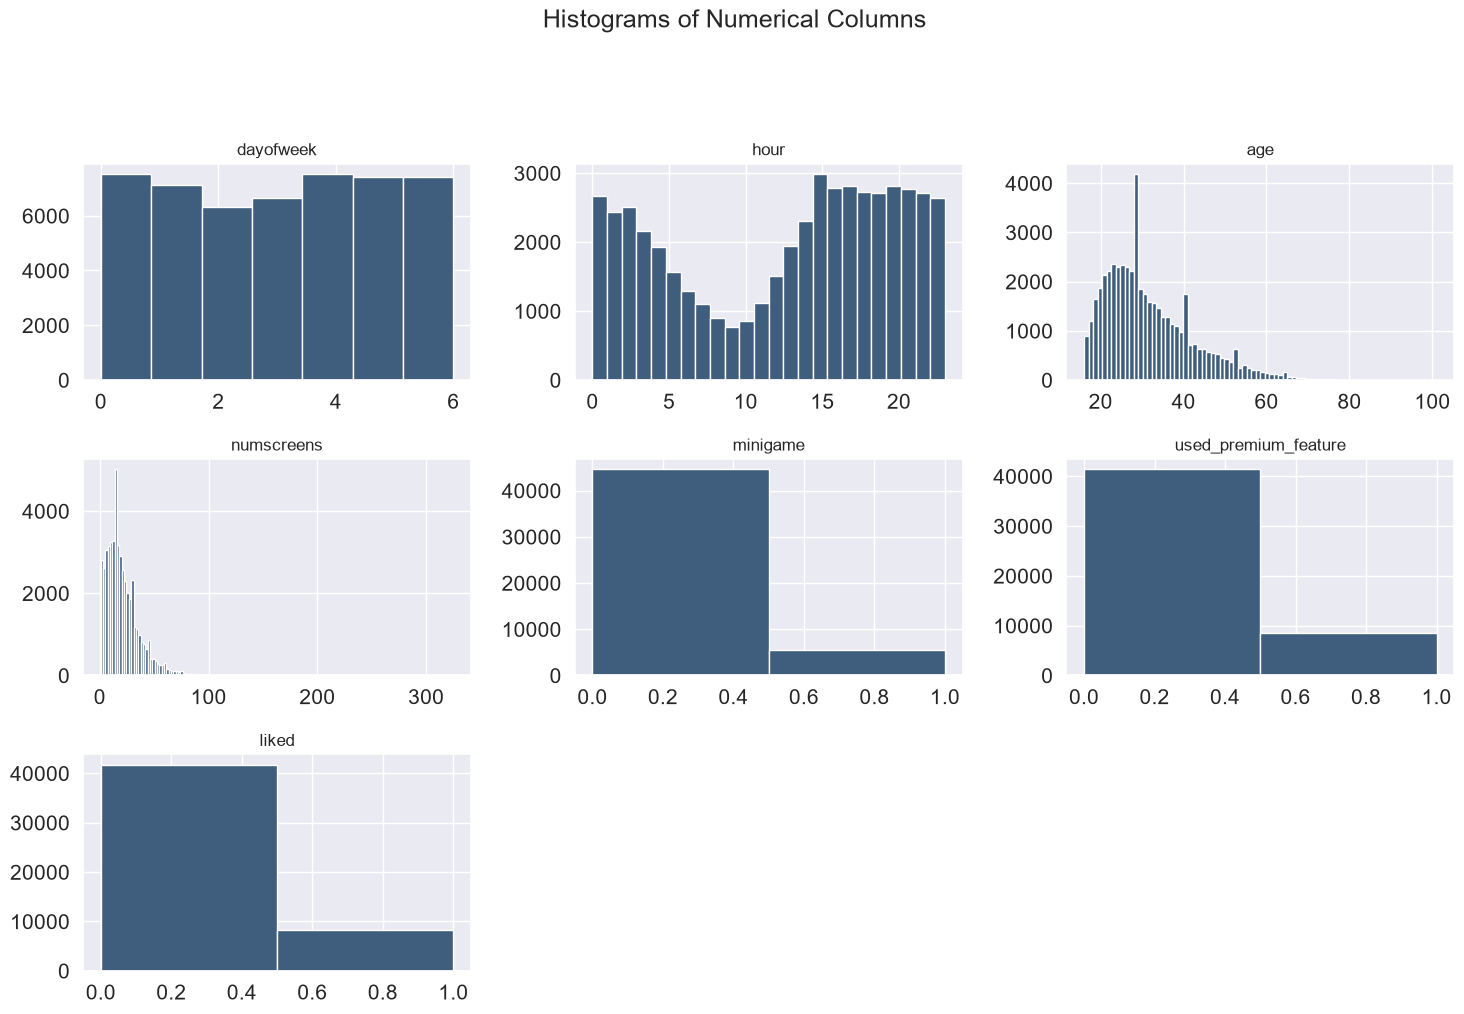

In [344]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure
plt.figure(figsize=(15, 10))

for i in range(1, dataset2.shape[1] + 1):
    plt.subplot(3, 3, i)

    vals = np.size(dataset2.iloc[:, i-1].unique())

    plt.hist(
        dataset2.iloc[:, i-1],
        bins=vals,
        color='#3F5D7D'
    )

    plt.title(
        dataset2.columns.values[i-1],
        fontsize=12
    )

# Overall title
plt.suptitle(
    'Histograms of Numerical Columns',
    fontsize=18,
    y=1.02
)

# Automatically adjust spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

### Correlation Plot

<Axes: title={'center': 'Correlation with Response Variable'}>

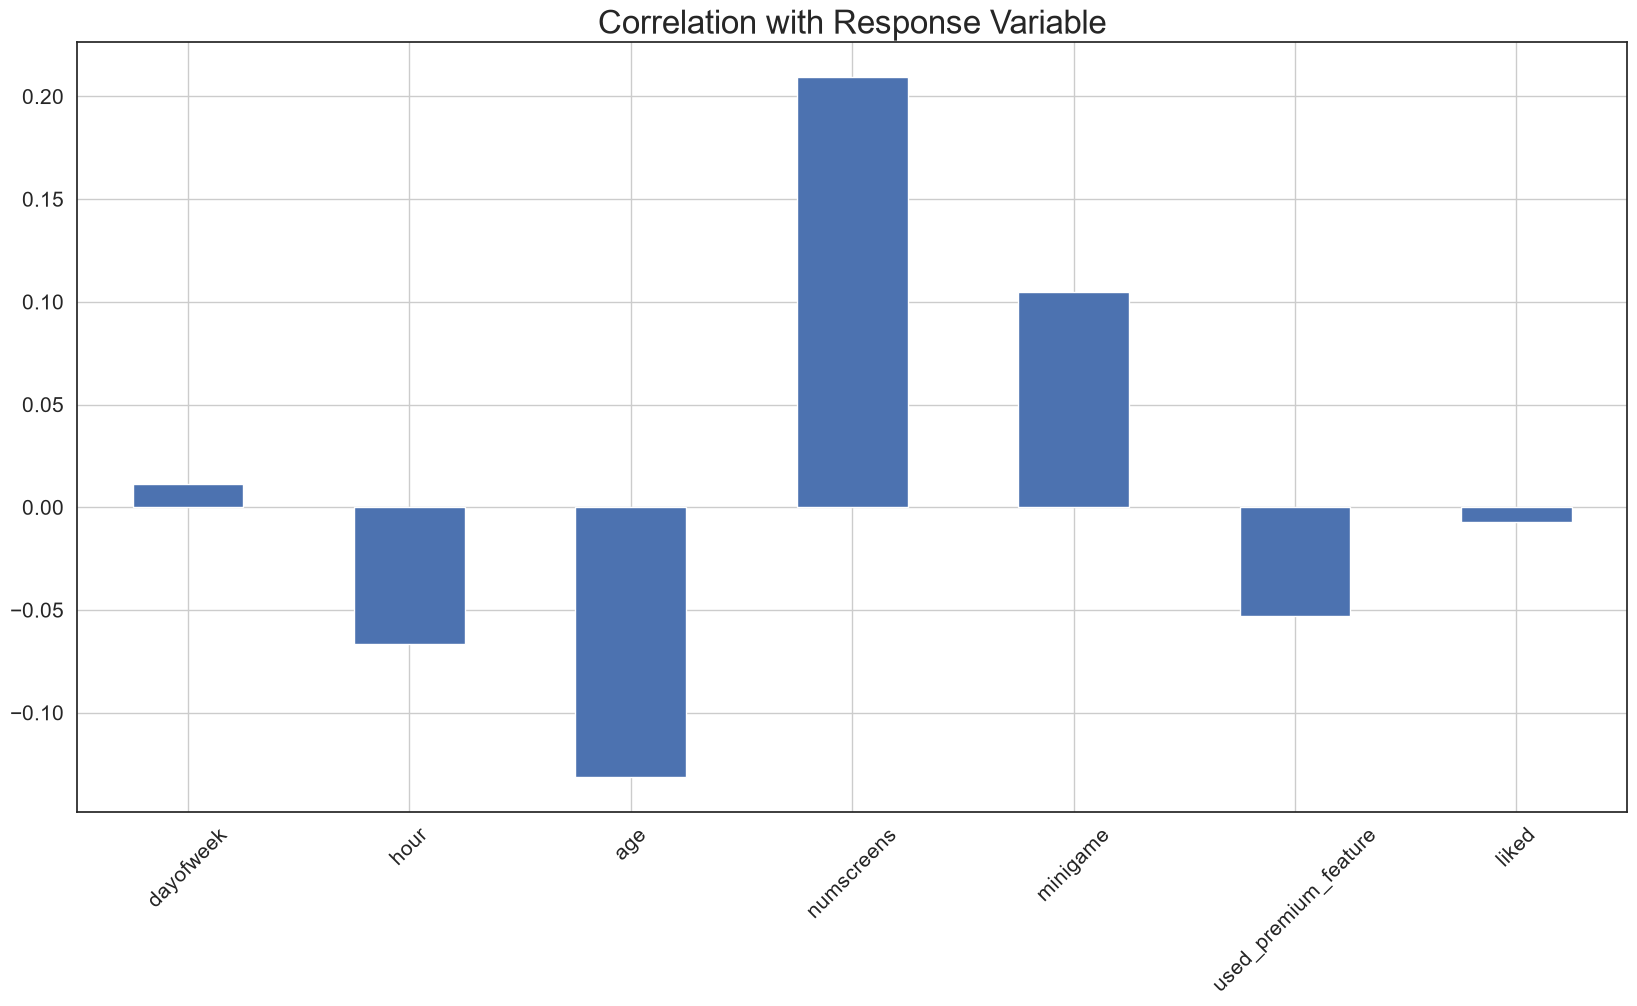

In [274]:
dataset2.corrwith(dataset.enrolled).plot.bar(figsize=(20,10),
                                            title='Correlation with Response Variable',
                                            fontsize=15,rot=45,
                                            grid=True)

### Correlation Matrix

<Axes: >

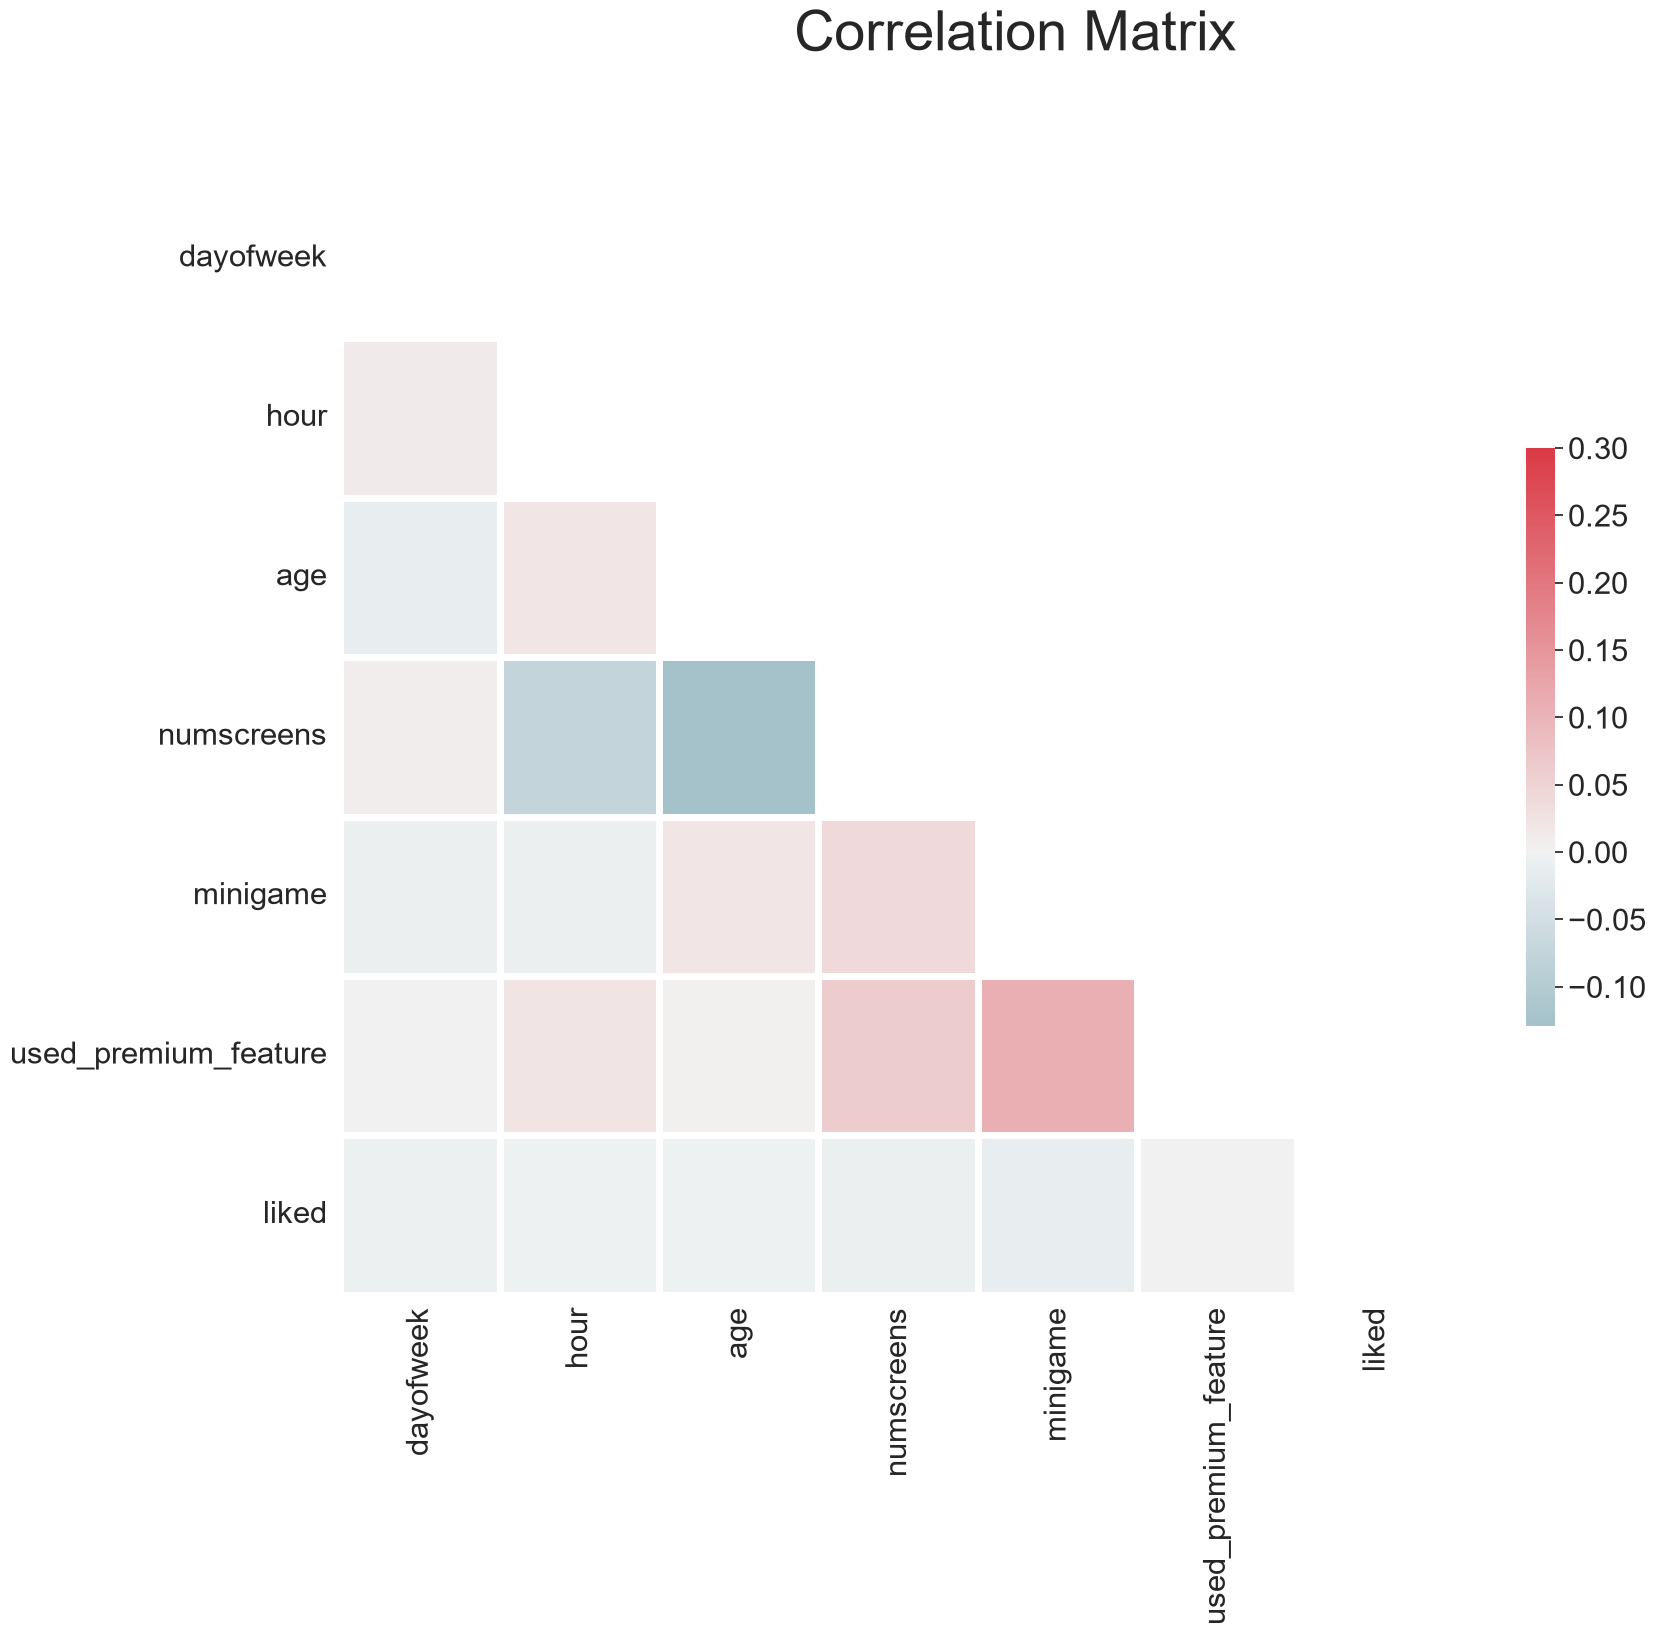

In [276]:
sn.set(style="white", font_scale=2)

# Compute the correlation matrix
corr=dataset2.corr()

# Generate a mask for the upper triangle
mask=np.zeros_like(corr,dtype=np.bool)
mask[np.triu_indices_from(mask)]=True

# Set up the matplotlib figure
f, ax=plt.subplots(figsize=(18,15))
f.suptitle("Correlation Matrix", fontsize=40)

# Generate a custom diverging colormap
cmap=sn.diverging_palette(220,10,as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sn.heatmap(corr,mask=mask,cmap=cmap,vmax=0.3, center=0,
           square=True, linewidths=5, cbar_kws={"shrink":0.5})

## Feature Engineering

In [278]:
dataset.dtypes

user                     int64
first_open              object
dayofweek                int64
hour                     int64
age                      int64
screen_list             object
numscreens               int64
minigame                 int64
used_premium_feature     int64
enrolled                 int64
enrolled_date           object
liked                    int64
dtype: object

In [279]:


dataset["first_open"] = [parser.parse(row_data) for row_data in dataset["first_open"]]
dataset["enrolled_date"] = [parser.parse(row_data) if isinstance(row_data, str) else row_data for row_data in dataset["enrolled_date"]]

In [280]:
dataset.dtypes

user                             int64
first_open              datetime64[ns]
dayofweek                        int64
hour                             int64
age                              int64
screen_list                     object
numscreens                       int64
minigame                         int64
used_premium_feature             int64
enrolled                         int64
enrolled_date           datetime64[ns]
liked                            int64
dtype: object

In [281]:
dataset["difference"] = (dataset["enrolled_date"] - dataset["first_open"]).dt.total_seconds() // 3600

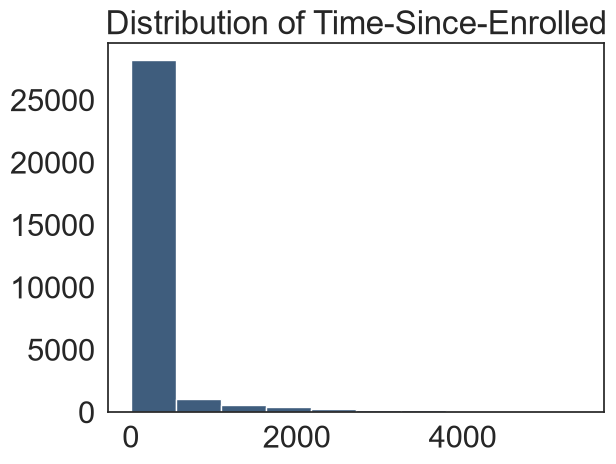

In [282]:
plt.hist(dataset["difference"].dropna(), color='#3F5D7D')
plt.title('Distribution of Time-Since-Enrolled')
plt.show()

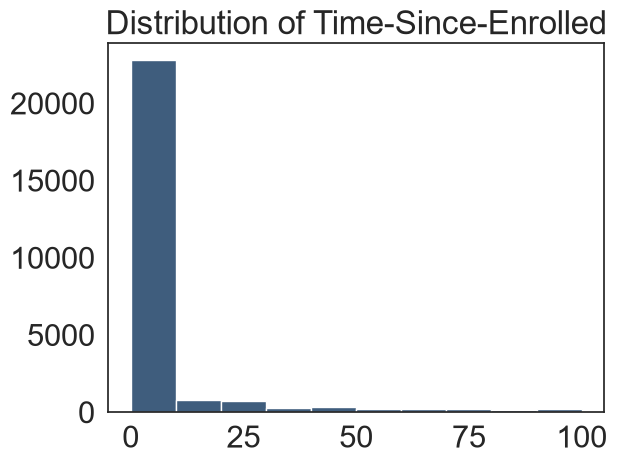

In [283]:
plt.hist(dataset["difference"].dropna(), color='#3F5D7D', range=[0,100])
plt.title('Distribution of Time-Since-Enrolled')
plt.show()

In [284]:
dataset.loc[dataset.difference>48,'enrolled']=0
dataset= dataset.drop(columns=['difference','enrolled_date','first_open'])

### Formatting the screen_list field

In [286]:
top_screens=pd.read_csv('top_screens.csv').top_screens.values

In [287]:
dataset["screen_list"]= dataset.screen_list.astype(str) + ','

In [288]:
for sc in top_screens:
    dataset[sc]= dataset.screen_list.str.contains(sc).astype(int)
    dataset["screen_list"]= dataset.screen_list.str.replace(sc+",","")

In [289]:
dataset["Other"]= dataset.screen_list.str.count(",")
dataset= dataset.drop(columns=["screen_list"])

In [290]:
# Funnels

savings_screens = ["Saving1",
                   "Saving2",
                   "Saving2Amount",
                   "Saving4",
                   "Saving5",
                   "Saving6",
                   "Saving7",
                   "Saving8",
                   "Saving9",
                   "Saving10"]

dataset["SavingsCount"] = dataset[savings_screens].sum(axis=1)
dataset= dataset.drop(columns=savings_screens)

cm_screens = ["Credit1",
              "Credit2",
              "Credit3",
              "Credit3Container",
              "Credit3Dashboard"]
dataset["CMCount"] = dataset[cm_screens].sum(axis=1)
dataset = dataset.drop(columns=cm_screens)

cc_screens = ["CC1",
              "CC1Category",
              "CC3"]
dataset["CCCount"] = dataset[cc_screens].sum(axis=1)
dataset = dataset.drop(columns=cc_screens)

loan_screens = ["Loan",
                "Loan2",
                "Loan3",
                "Loan4"]
dataset["LoansCount"] = dataset[loan_screens].sum(axis=1)
dataset = dataset.drop(columns=loan_screens)

In [291]:
dataset.head()

,user,dayofweek,hour,age,numscreens,minigame,used_premium_feature,enrolled,liked,location,...,SecurityModal,ResendToken,TransactionList,NetworkFailure,ListPicker,Other,SavingsCount,CMCount,CCCount,LoansCount
0,235136,3,2,23,15,0,0,0,0,0,...,0,0,0,0,0,7,0,0,0,1
1,333588,6,1,24,13,0,0,0,0,1,...,0,0,0,0,0,5,0,0,0,1
2,254414,1,19,23,3,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,234192,4,16,28,40,0,0,1,0,1,...,0,0,0,0,0,6,0,3,0,1
4,51549,1,18,31,32,0,0,1,1,0,...,0,0,0,0,0,10,0,2,0,1


In [292]:
dataset.describe()

,user,dayofweek,hour,age,numscreens,minigame,used_premium_feature,enrolled,liked,location,...,SecurityModal,ResendToken,TransactionList,NetworkFailure,ListPicker,Other,SavingsCount,CMCount,CCCount,LoansCount
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000
mean,186889.729900,3.029860,12.557220,31.72436,21.095900,0.107820,0.172020,0.497000,0.165000,0.517760,...,0.014220,0.013340,0.013400,0.008200,0.007580,6.214260,0.365020,0.92776,0.176860,0.788400
std,107768.520361,2.031997,7.438072,10.80331,15.728812,0.310156,0.377402,0.499996,0.371184,0.499689,...,0.118398,0.114727,0.114981,0.090183,0.086733,3.672561,1.405511,1.21751,0.612787,0.677462
min,13.000000,0.000000,0.000000,16.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,93526.750000,1.000000,5.000000,24.00000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.00000,0.000000,0.000000
50%,187193.500000,3.000000,14.000000,29.00000,18.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.00000,0.000000,1.000000
75%,279984.250000,5.000000,19.000000,37.00000,28.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,1.00000,0.000000,1.000000
max,373662.000000,6.000000,23.000000,101.00000,325.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,35.000000,10.000000,5.00000,3.000000,3.000000


In [293]:
dataset.columns

Index(['user', 'dayofweek', 'hour', 'age', 'numscreens', 'minigame',
       'used_premium_feature', 'enrolled', 'liked', 'location', 'Institutions',
       'VerifyPhone', 'BankVerification', 'VerifyDateOfBirth', 'ProfilePage',
       'VerifyCountry', 'Cycle', 'idscreen', 'Splash', 'RewardsContainer',
       'EditProfile', 'Finances', 'Alerts', 'Leaderboard', 'VerifyMobile',
       'VerifyHousing', 'RewardDetail', 'VerifyHousingAmount',
       'ProfileMaritalStatus', 'ProfileChildren ', 'ProfileEducation',
       'ProfileEducationMajor', 'Rewards', 'AccountView', 'VerifyAnnualIncome',
       'VerifyIncomeType', 'ProfileJobTitle', 'Login',
       'ProfileEmploymentLength', 'WebView', 'SecurityModal', 'ResendToken',
       'TransactionList', 'NetworkFailure', 'ListPicker', 'Other',
       'SavingsCount', 'CMCount', 'CCCount', 'LoansCount'],
      dtype='object')

In [294]:
dataset.to_csv("new_appdata10.csv", index=False)

In [295]:
import time

## Data Preprocessing

In [308]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
import time

dataset = pd.read_csv('new_appdata10.csv')

# Data Preprocessing

response = dataset["enrolled"]
dataset = dataset.drop(columns='enrolled')

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(dataset, response,
                                                    test_size=0.2,
                                                    random_state=0)

train_identifier = X_train['user']
X_train = X_train.drop(columns='user')
test_identifier = X_test['user']
X_test = X_test.drop(columns='user')

from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train2 = pd.DataFrame(sc_X.fit_transform(X_train))
X_test2 = pd.DataFrame(sc_X.transform(X_test))
X_train2.columns = X_train.columns.values
X_test2.columns = X_test.columns.values
X_train2.index = X_train.index.values
X_test2.index = X_test.index.values
X_train = X_train2
X_test = X_test2

## Model Building

In [319]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0, penalty='l1', solver='liblinear')
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
cm = confusion_matrix(y_test, y_pred)
accuracy_score(y_test, y_pred)

0.7681

In [321]:
precision_score(y_test,y_pred)

0.7618952017667135

In [323]:
recall_score(y_test,y_pred)

0.7700892857142857

In [325]:
f1_score(y_test,y_pred)

0.7659703300030275

Test Data Accuracy: 0.7681


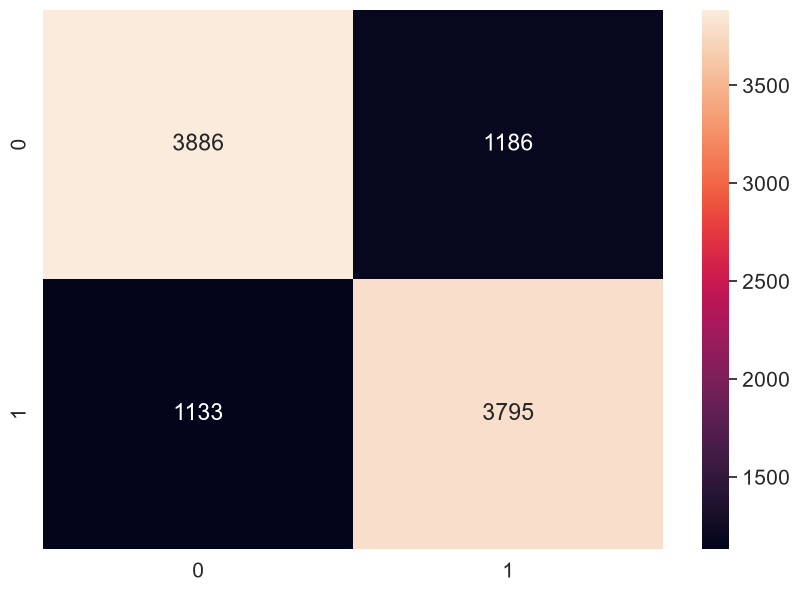

In [327]:
df_cm = pd.DataFrame(cm, index=(0, 1), columns=(0, 1))
plt.figure(figsize=(10, 7))
sn.set(font_scale=1.4)
sn.heatmap(df_cm, annot=True, fmt='g')
print("Test Data Accuracy: %0.4f" % accuracy_score(y_test, y_pred))

In [329]:
from sklearn.model_selection import cross_val_score
accuracies= cross_val_score(estimator=classifier, X=X_train,y=y_train,cv=10)

In [333]:
print("Logistic Accuracy: %0.3f(+/- %0.3f)" % (accuracies.mean(), accuracies.std()*2))

Logistic Accuracy: 0.767(+/- 0.009)


## Formatting the Final Result

In [336]:
final_results= pd.concat([y_test, test_identifier],axis=1).dropna()

In [338]:
final_results['predicted_results']=y_pred

In [340]:
final_results[['user','enrolled','predicted_results']].reset_index(drop=True)

,user,enrolled,predicted_results
0,239786,1,1
1,279644,1,1
2,98290,0,0
3,170150,1,1
4,237568,1,1
...,...,...,...
9995,143036,1,0
9996,91158,1,1
9997,248318,0,0
9998,142418,1,1


## Conclusion


- **Goal achieved:** The project built a model that labels each new app user as "likely" or "unlikely" to subscribe to the paid product, based on early in-app behavior.
- **Model and performance:** A logistic regression classifier with L1 regularization reached a test accuracy of about 76.8%, and 10-fold cross-validation confirmed the performance is consistent across different subsets of the data.
- **Validation step:** Predictions can be tested on daily new installs to check that accuracy holds steady over time before the model is fully relied on.
- **Targeted marketing:** Users predicted as likely to subscribe already tend to convert, so they need only light promotion. Marketing effort and discounts can be focused on users predicted as unlikely to subscribe.
- **Business impact:** The benefit of the model can be measured by the increase in overall subscriptions after targeted campaigns begin.
- **Offer strategy:** Well-designed offers, such as a free first month or 50% off an annual plan, can convert hesitant users into paying subscribers.
- **Long-term value:** Offers like discounted annual plans lock users in for an extended period, so the company gains overall value even at a reduced price.